In [1]:
import pandas as pd

In [3]:
data = pd.read_csv('../data/US-pumpkins.csv')

In [4]:
data.head

<bound method NDFrame.head of       City Name Type        Package      Variety Sub Variety  Grade     Date  \
0     BALTIMORE  NaN   24 inch bins          NaN         NaN    NaN  4/29/17   
1     BALTIMORE  NaN   24 inch bins          NaN         NaN    NaN   5/6/17   
2     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
3     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
4     BALTIMORE  NaN   24 inch bins  HOWDEN TYPE         NaN    NaN  11/5/16   
...         ...  ...            ...          ...         ...    ...      ...   
1752  ST. LOUIS  NaN  22 lb cartons    MINIATURE   FLAT TYPE    NaN  9/30/16   
1753  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/26/16   
1754  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/27/16   
1755  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/28/16   
1756  ST. LOUIS  NaN   36 inch bins    MINIATURE  ROUND TYPE    NaN  9/29/16   

      Low

In [7]:
data.isnull().sum()

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

In [25]:
columns_sel = ["Package",'Low Price','High Price', 'Date']
pumpkins = data.loc[:,columns_sel][data['Package'].str.contains('bushel',case=True,regex=True)]

In [26]:
pumpkins['Price'] = (pumpkins['Low Price'] + pumpkins['High Price']) /2
pumpkins['Month'] = pd.DatetimeIndex(pumpkins['Date']).month
pumpkins.head(), pumpkins.describe()

(                 Package  Low Price  High Price     Date  Price  Month
 70  1 1/9 bushel cartons       15.0        15.0  9/24/16   15.0      9
 71  1 1/9 bushel cartons       18.0        18.0  9/24/16   18.0      9
 72  1 1/9 bushel cartons       18.0        18.0  10/1/16   18.0     10
 73  1 1/9 bushel cartons       17.0        17.0  10/1/16   17.0     10
 74  1 1/9 bushel cartons       15.0        15.0  10/8/16   15.0     10,
         Low Price  High Price       Price       Month
 count  415.000000  415.000000  415.000000  415.000000
 mean    18.007831   18.989759   18.498795    9.838554
 std      5.273335    5.694920    5.424388    0.748885
 min     10.750000   12.000000   12.000000    8.000000
 25%     15.000000   17.000000   16.500000    9.000000
 50%     17.000000   18.000000   17.000000   10.000000
 75%     18.000000   19.000000   19.000000   10.000000
 max     48.000000   55.000000   51.500000   12.000000)

In [27]:
pumpkins.loc[pumpkins['Package'].str.contains('1 1/9'),'Price'] = pumpkins['Price']/(1+1/9)
pumpkins.loc[pumpkins['Package'].str.contains('1/2'),'Price'] = pumpkins['Price']/(1/2)

In [28]:
pumpkins.describe()

,Low Price,High Price,Price,Month
count,415.000000,415.000000,415.000000,415.000000
mean,18.007831,18.989759,27.656506,9.838554
std,5.273335,5.694920,9.876318,0.748885
min,10.750000,12.000000,10.800000,8.000000
25%,15.000000,17.000000,16.200000,9.000000
50%,17.000000,18.000000,30.000000,10.000000
75%,18.000000,19.000000,35.000000,10.000000
max,48.000000,55.000000,51.500000,12.000000


In [22]:
import matplotlib.pyplot as plt

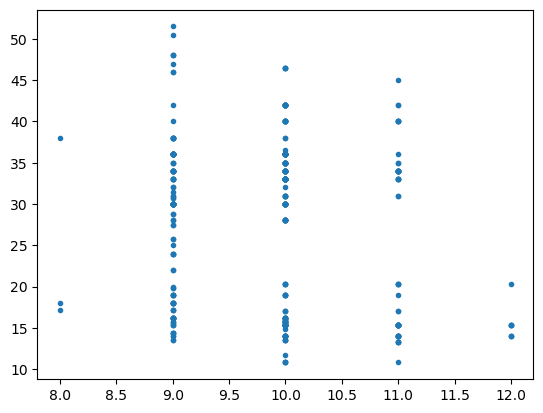

In [35]:
plt.plot(pumpkins.Month,pumpkins.Price,'.')

<Axes: xlabel='Month'>

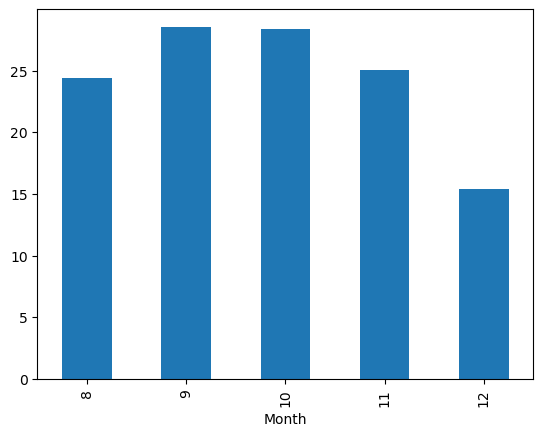

In [38]:
pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')